In [ ]:
from keras.utils import to_categorical
from keras.preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense , Conv2D , Dropout , Flatten , MaxPooling2D
from tqdm import tqdm
# import PIL.Image as pi
import os
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')
import seaborn as sns

## Load the Dataset
Download Dataset: https://drive.google.com/file/d/1SpJTN-oiMHwArdw-GFS8Bge6ZQrYq00R/view?usp=sharing

In [ ]:
TRAIN_DIR = "dataset/train"
TEST_DIR  ="dataset/test" 

In [82]:
def createDataFrame(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imageName in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imageName))
            labels.append(label)
        print(label , "Completed")
    return image_paths,labels

In [83]:
# Convert into DataFrame
train = pd.DataFrame()
train['image'] , train['label'] = createDataFrame(TRAIN_DIR)
# Shuffle the Dataset
# train = train.sample(frac=1).reset_index(drop=True)
train.head()

angry Completed
disgust Completed
fear Completed
happy Completed
neutral Completed
sad Completed
surprise Completed


,image,label
0,images/train\angry\0.jpg,angry
1,images/train\angry\1.jpg,angry
2,images/train\angry\10.jpg,angry
3,images/train\angry\10002.jpg,angry
4,images/train\angry\10016.jpg,angry


In [84]:
test = pd.DataFrame()
test['image'] , test['label'] = createDataFrame(TEST_DIR)
test.head()

angry Completed
disgust Completed
fear Completed
happy Completed
neutral Completed
sad Completed
surprise Completed


,image,label
0,images/test\angry\10052.jpg,angry
1,images/test\angry\10065.jpg,angry
2,images/test\angry\10079.jpg,angry
3,images/test\angry\10095.jpg,angry
4,images/test\angry\10121.jpg,angry


## Exploratory Data Analysis

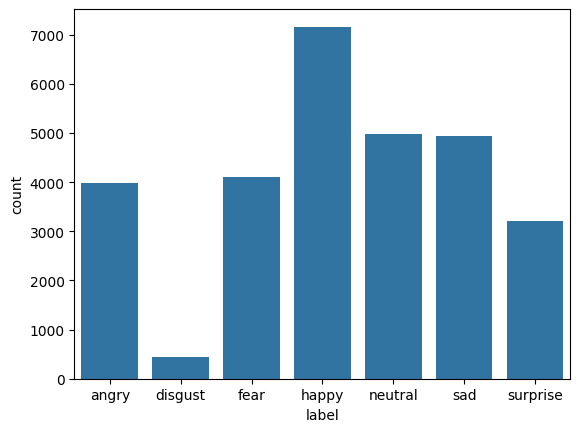

In [85]:
sns.countplot(orient='h',x=train['label']);

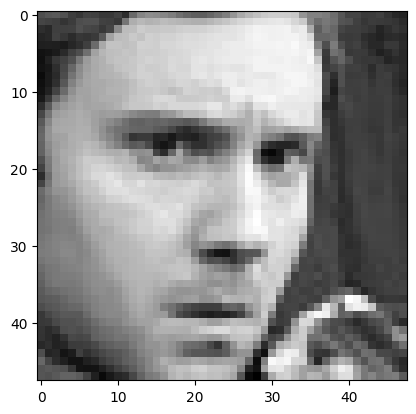

In [86]:
from PIL import Image
img = Image.open(train['image'][0])
plt.imshow(img,cmap='gray');

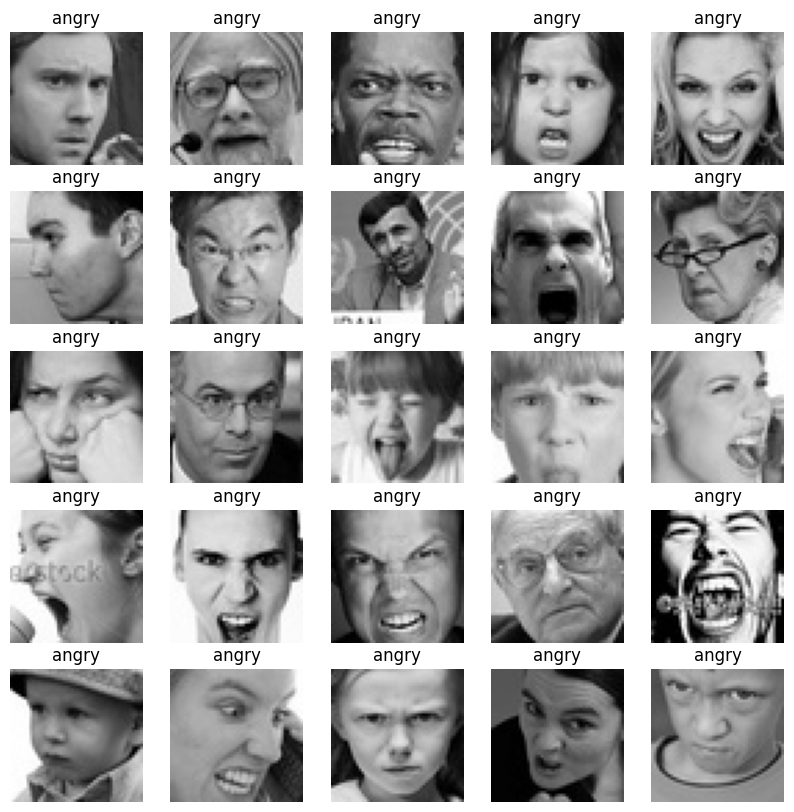

In [87]:
# to display the grid of images
plt.figure(figsize=(10,10))
files = train.iloc[0:25]

for index, file, label in files.itertuples():
    plt.subplot(5,5,index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

## Feature Extraction

In [88]:
def extractFeatures(images):
    try:
        features = []
        for image in tqdm(images):
            img = load_img(image, color_mode="grayscale", target_size=(48, 48,1))
            img = np.array(img)
            features.append(img)
        features = np.array(features)
        return features
    except Exception as e:
        print(e)

In [89]:
trainFeatures = extractFeatures(train['image'])

100%|███████████████████████████████████████████████████████████████████████████| 28821/28821 [01:05<00:00, 441.38it/s]


In [90]:
testFeatures = extractFeatures(test['image'])

100%|█████████████████████████████████████████████████████████████████████████████| 7066/7066 [00:16<00:00, 425.03it/s]


In [91]:
# Normalize the image
x_train = trainFeatures/255.0
x_test  = testFeatures/255.0

In [92]:
# convert label to integer
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(train['label'])
y_train = le.transform(train['label'])
y_test  = le.transform(test['label'])

In [93]:
y_train = to_categorical(y_train,num_classes=7)
y_test  = to_categorical(y_test,num_classes=7)

In [94]:
# config
input_shape = (48,48,1)
output_class = 7

## Model Creation

In [95]:
model = Sequential()
# convolutional Layers
model.add(Conv2D(128,kernel_size=(3,3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))   # 40% Dropout Layer

model.add(Conv2D(256,kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512,kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512,kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
          
# Fully connected layers
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3))
# Output Layer
model.add(Dense(7, activation='softmax'))


In [96]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [97]:
model.fit(x=x_train, y=y_train,batch_size=128,epochs=100,validation_data= (x_test,y_test))

Epoch 1/100
 11/226 ━━━━━━━━━━━━━━━━━━━━ 12:48 4s/step - accuracy: 0.1841 - loss: 1.9192


KeyboardInterrupt



## Test with Image Data

In [98]:
from keras.models import model_from_json
json_file = open("emotionDection.json",'r')
model_json = json_file.read()
json_file.close()
model = model_from_json(model_json)
model.load_weights("emotionDection.h5")

Original Output::  happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicated Output::  happy


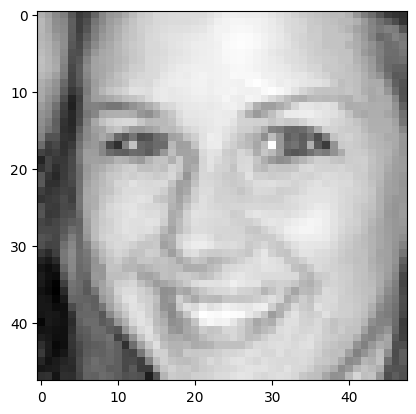

In [111]:
import random
image_index = random.randint(0, len(test))
print("Original Output:: ", test['label'][image_index])
pred = model.predict(x_test[image_index].reshape(1, 48, 48, 1))
prediction_label = le.inverse_transform([pred.argmax()])[0]
print("Predicated Output:: ", prediction_label)
plt.imshow(x_test[image_index].reshape(48,48),cmap='gray');

Original Output::  neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicated Output::  neutral


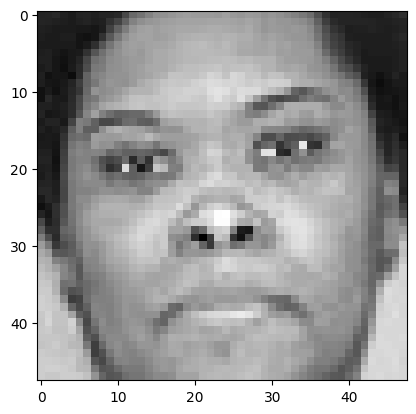

In [125]:
image_index = random.randint(0, len(test))
print("Original Output:: ", test['label'][image_index])
pred = model.predict(x_test[image_index].reshape(1, 48, 48, 1))
prediction_label = le.inverse_transform([pred.argmax()])[0]
print("Predicated Output:: ", prediction_label)
plt.imshow(x_test[image_index].reshape(48,48),cmap='gray');